In [5]:
# Imports 
import pandas as pd
import html
from matplotlib import pyplot as plt
from sklearn.metrics import cohen_kappa_score, accuracy_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV


# FEATURE REPRESENTATION 
# TFIDF vectorizer
def tfidf_vectorize(corpus):
    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(corpus)
    return X

# BoW vectorizer
def bow_vectorize(corpus):
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(corpus)
    return X

# Word embeddings vectorizer (OM VI VILL ANVÄNDA DEN)
def word_embeddings_vectorize(corpus, embedding_model):
    pass


# CLASSIFIER 1: Naive Bayes
# Skriv lite mer om Naive Bayes HÄR
def train_naive_bayes_pipeline():
    model = Pipeline([
        ("vectorizer", TfidfVectorizer()),
        ("classifier", MultinomialNB())
    ])
    return model


# CLASSIFIER 2: Logistic Regression
# Skriv lite mer om Logistic Regression HÄR
def train_logistic_regression_pipeline():
    model = Pipeline([
        ("vectorizer", TfidfVectorizer()),
        ("classifier", LogisticRegression(max_iter=1000))
    ])
    return model

# CLASSIFIER 3: Support Vector Classifier (SVC)
# Skriv lite mer om SVC HÄR
def train_svc_pipeline():
    model = Pipeline([
        ("vectorizer", TfidfVectorizer()),
        ("classifier", SVC(kernel='linear'))
    ])
    return model


def test_train_split(X, y, test_size=0.2):
    (X_train, X_test, y_train, y_test) = train_test_split(
        X, y, test_size=test_size, random_state=1337
    )
    return X_train, X_test, y_train, y_test


def agreement_accuracy_score(crowd, gold):
    df = crowd.merge(gold, on="text", suffixes=("_crowd", "_gold"))

    print("Aligned rows:", len(df))

    kappa = cohen_kappa_score(
        df["sentiment_crowd"],
        df["sentiment_gold"]
    )

    acc = accuracy_score(
        df["sentiment_crowd"],
        df["sentiment_gold"]
    )

    return (kappa, acc)


# helper function to plot kappa and accuracy scores for all models
def plot_model_kappa_accuracy(kappa_scores, acc_scores, str):
    models = ["Majority Class", "Naive Bayes", "Logistic Regression", "SVC"]
    x = range(len(models))

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    bars0 = plt.bar(x, [score + 1 for score in kappa_scores], bottom=-1,color = ['red','green','blue', 'orange'])
    plt.bar_label(bars0, labels=[f"{s:.2f}" for s in kappa_scores])
    plt.xticks(x, models)
    plt.title('Kappa Scores by Model')
    plt.ylabel('Kappa Score')

    plt.subplot(1, 2, 2)
    bars1 = plt.bar(x, acc_scores, color = ['red','green','blue', 'orange'])
    plt.bar_label(bars1, labels=[f"{s:.2f}" for s in acc_scores])

    plt.xticks(x, models)
    plt.title('Accuracy Scores by Model')
    plt.ylabel('Accuracy Score')

    plt.tight_layout()
    plt.savefig(f"plots/model_kappa_accuracy_{str}.png")
    plt.show


def feature_processing(cs):
    # replace twitter handles with @USER
    cs["text"] = cs["text"].str.replace(r"\B@\w+", "@USER", regex=True)

    # fix html unicode
    cs["text"] = cs["text"].apply(html.unescape)

    # remove URLs
    cs["text"] = cs["text"].str.replace(r"http\S+|www\.\S+", "", regex=True)

In [10]:
# read/ load data
cs_train = pd.read_csv("data/crowdsourced_train.csv", sep="\t")
gold_train = pd.read_csv("data/gold_train.csv", sep="\t")

# normalize sentiment labels
cs_train["sentiment"] = cs_train["sentiment"].str.lower().str.strip()
gold_train["sentiment"] = gold_train["sentiment"].str.lower().str.strip()

# keep only valid labels
valid_labels = ["positive", "negative", "neutral"]
cs_train = cs_train[cs_train["sentiment"].isin(valid_labels)]
gold_train = gold_train[gold_train["sentiment"].isin(valid_labels)]

# preprocessing
feature_processing(cs_train)
feature_processing(gold_train)

# agreement scores
agr_score, acc_score = agreement_accuracy_score(cs_train, gold_train)
print("Agreement score (kappa): ", agr_score)
print("Accuracy score: ", acc_score)

# Use raw text directly (Pipeline handles vectorization!)
X_gold = gold_train["text"]
y_gold = gold_train["sentiment"]

X_cs = cs_train["text"]
y_cs = cs_train["sentiment"]

Aligned rows: 10634
Agreement score (kappa):  0.4463044126341811
Accuracy score:  0.6546924957682904


Majority class Kappa : 0.0
Majority class Accuracy : 0.4745157043445552
Naive Bayes Kappa : 0.11694435404345294
Naive Bayes Accuracy : 0.5213916314057357
Logistic Regression Kappa : 0.27967638781451587
Logistic Regression Accuracy : 0.5665256229431124
SVC Kappa : 0.2864448265131133
SVC Accuracy : 0.5712270803949224


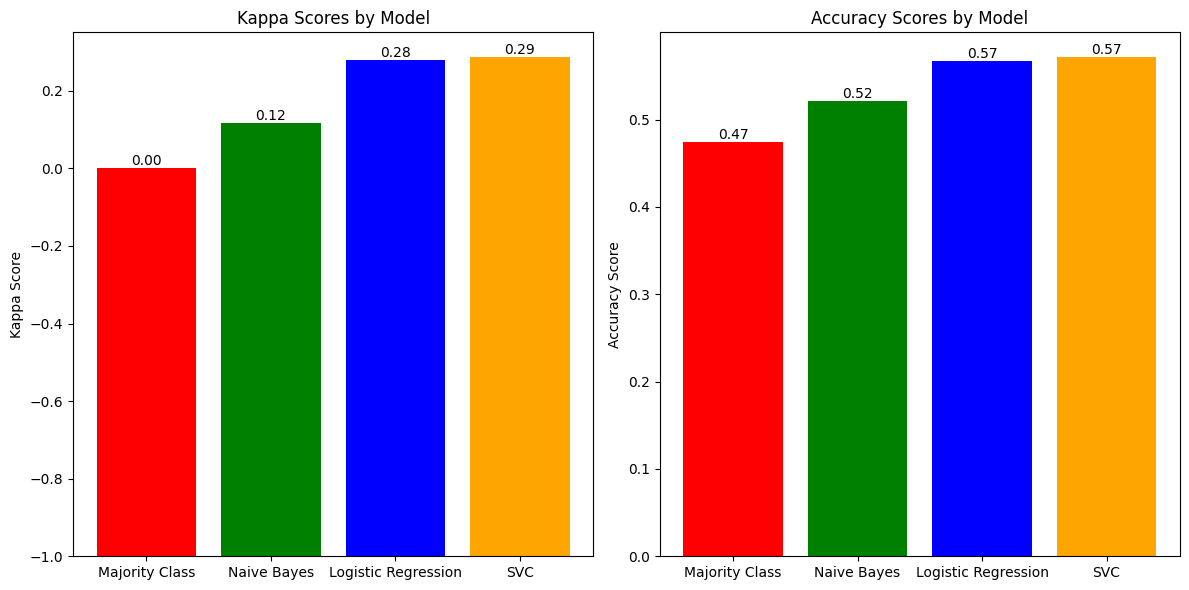

In [11]:
# Majority class baseline
majority_class = y_cs.mode()[0]
majority_predictions = [majority_class] * len(y_cs)
majority_kappa = cohen_kappa_score(majority_predictions, y_cs)
majority_acc = accuracy_score(majority_predictions, y_cs)

print("Majority class Kappa :", majority_kappa)
print("Majority class Accuracy :", majority_acc)

# Naive Bayes Model
X_train_nb, X_test_nb, y_train_nb, y_test_nb = test_train_split(X_cs, y_cs)
nb_model = train_naive_bayes_pipeline()
nb_model.fit(X_train_nb, y_train_nb)
nb_predictions = nb_model.predict(X_test_nb)

nb_kappa = cohen_kappa_score(nb_predictions, y_test_nb)
nb_acc = accuracy_score(nb_predictions, y_test_nb)

print("Naive Bayes Kappa :", nb_kappa)
print("Naive Bayes Accuracy :", nb_acc)

# Logistic Regression Model
X_train_lr, X_test_lr, y_train_lr, y_test_lr = test_train_split(X_cs, y_cs)
lr_model = train_logistic_regression_pipeline()
lr_model.fit(X_train_lr, y_train_lr)
lr_predictions = lr_model.predict(X_test_lr)

lr_kappa = cohen_kappa_score(lr_predictions, y_test_lr)
lr_acc = accuracy_score(lr_predictions, y_test_lr)

print("Logistic Regression Kappa :", lr_kappa)
print("Logistic Regression Accuracy :", lr_acc)

# SVC Model
X_train_svc, X_test_svc, y_train_svc, y_test_svc = test_train_split(X_cs, y_cs)
svc_model = train_svc_pipeline()
svc_model.fit(X_train_svc, y_train_svc)
svc_predictions = svc_model.predict(X_test_svc)

svc_kappa = cohen_kappa_score(svc_predictions, y_test_svc)
svc_acc = accuracy_score(svc_predictions, y_test_svc)

print("SVC Kappa :", svc_kappa)
print("SVC Accuracy :", svc_acc)

# plot results
kappa_scores = [majority_kappa, nb_kappa, lr_kappa, svc_kappa]
acc_scores = [majority_acc, nb_acc, lr_acc, svc_acc]
plot_model_kappa_accuracy(kappa_scores, acc_scores, "initial")

Best Naive Bayes Parameters:  {'classifier__alpha': 0.1, 'vectorizer__ngram_range': (1, 2)}
Best Logistic Regression Parameters:  {'classifier__C': 1, 'vectorizer__ngram_range': (1, 1)}
Tuned Naive Bayes Kappa : 0.22674202214648076
Tuned Naive Bayes Accuracy : 0.5453690644099671
Tuned Logistic Regression Kappa : 0.27967638781451587
Tuned Logistic Regression Accuracy : 0.5665256229431124


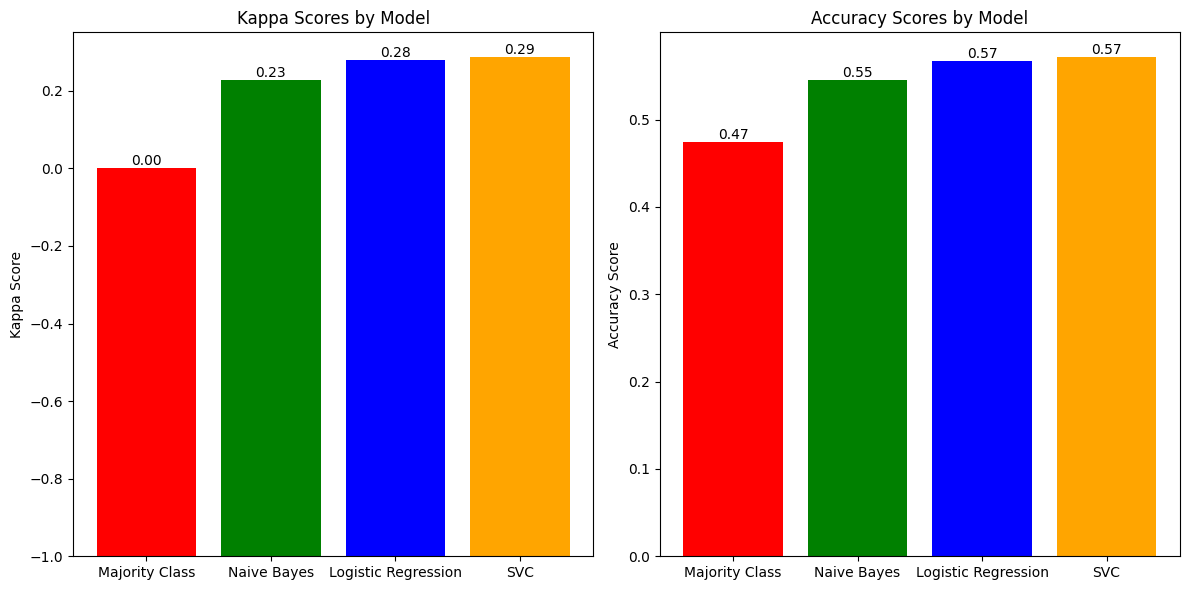

In [16]:
# Tune Hyperparameters for Naive Bayes, Logistic Regression, and SVC using GridSearchCV

# Naive Bayes Hyperparameter Tuning
nb_param_grid = {
    'vectorizer__ngram_range': [(1, 1), (1, 2)],
    'classifier__alpha': [0.01, 0.1, 1]
}
nb_grid_search = GridSearchCV(train_naive_bayes_pipeline(), nb_param_grid, cv=5, n_jobs=-1)
nb_grid_search.fit(X_cs, y_cs)
print("Best Naive Bayes Parameters: ", nb_grid_search.best_params_)

# Logistic Regression Hyperparameter Tuning
lr_param_grid = {
    'vectorizer__ngram_range': [(1, 1), (1, 2)],
    'classifier__C': [0.01, 0.1, 1]
}
lr_grid_search = GridSearchCV(train_logistic_regression_pipeline(), lr_param_grid, cv=5, n_jobs=-1)
lr_grid_search.fit(X_cs, y_cs)
print("Best Logistic Regression Parameters: ", lr_grid_search.best_params_)
'''
# SVC Hyperparameter Tuning
svc_param_grid = {
    'vectorizer__ngram_range': [(1, 1), (1, 2)],
    'classifier__C': [0.01, 0.1, 1],
    'classifier__kernel': ['linear', 'rbf']
}
svc_grid_search = GridSearchCV(train_svc_pipeline(), svc_param_grid, cv=5, n_jobs=-1)
svc_grid_search.fit(X_cs, y_cs)
print("Best SVC Parameters: ", svc_grid_search.best_params_)
'''

# run models again and use best hyperparameters to evaluate on test set
# Naive Bayes with best hyperparameters
nb_best_model = Pipeline([
    ("vectorizer", TfidfVectorizer(ngram_range=nb_grid_search.best_params_['vectorizer__ngram_range'])),
    ("classifier", MultinomialNB(alpha=nb_grid_search.best_params_['classifier__alpha']))
])
nb_best_model.fit(X_train_nb, y_train_nb)
nb_best_predictions = nb_best_model.predict(X_test_nb)
nb_best_kappa = cohen_kappa_score(nb_best_predictions, y_test_nb)
nb_best_acc = accuracy_score(nb_best_predictions, y_test_nb)
print("Tuned Naive Bayes Kappa :", nb_best_kappa)
print("Tuned Naive Bayes Accuracy :", nb_best_acc)

# Logistic Regression with best hyperparameters
lr_best_model = Pipeline([
    ("vectorizer", TfidfVectorizer(ngram_range=lr_grid_search.best_params_['vectorizer__ngram_range'])),
    ("classifier", LogisticRegression(C=lr_grid_search.best_params_['classifier__C'], max_iter=1000))
])
lr_best_model.fit(X_train_lr, y_train_lr)
lr_best_predictions = lr_best_model.predict(X_test_lr)
lr_best_kappa = cohen_kappa_score(lr_best_predictions, y_test_lr)
lr_best_acc = accuracy_score(lr_best_predictions, y_test_lr)
print("Tuned Logistic Regression Kappa :", lr_best_kappa)
print("Tuned Logistic Regression Accuracy :", lr_best_acc)

# SVC with best hyperparameters
'''
svc_best_model = Pipeline([
    ("vectorizer", TfidfVectorizer(ngram_range=svc_grid_search.best_params_['vectorizer__ngram_range'])),
    ("classifier", SVC(C=svc_grid_search.best_params_['classifier__C'], kernel=svc_grid_search.best_params_['classifier__kernel']))
])
svc_best_model.fit(X_train_svc, y_train_svc)
svc_best_predictions = svc_best_model.predict(X_test_svc)
svc_best_kappa = cohen_kappa_score(svc_best_predictions, y_test_svc)
svc_best_acc = accuracy_score(svc_best_predictions, y_test_svc)
print("Tuned SVC Kappa :", svc_best_kappa)
print("Tuned SVC Accuracy :", svc_best_acc)
'''
# The reason for not using the tunes SVC model is that it does not yield better results than the initial SVC model.

svc_best_kappa = svc_kappa  # Placeholder, replace with actual tuned kappa
svc_best_acc = svc_acc  # Placeholder, replace with actual tuned accuracy

# plot results for tuned models
tuned_kappa_scores = [majority_kappa, nb_best_kappa, lr_best_kappa, svc_best_kappa]
tuned_acc_scores = [majority_acc, nb_best_acc, lr_best_acc, svc_best_acc]
plot_model_kappa_accuracy(tuned_kappa_scores, tuned_acc_scores, "tuned")
